# 🏀 Ball Trajectory Prediction using Deep Learning

## Ujian Tengah Semester (UTS) - Deep Learning (Kelas B)

**Tujuan Proyek:**  
Memprediksi trajektori (lintasan koordinat X dan Y) bola basket di masa depan berdasarkan rekaman pergerakan di beberapa frame sebelumnya dalam sebuah video, menggunakan arsitektur Deep Learning berbasis sekuensial: **Simple RNN**, **LSTM**, dan **GRU**.

**Pipeline End-to-End:**
1. Ekstraksi & Tracking Objek (YOLOv8)
2. Data Engineering - CSV Exporter
3. Train/Test Split Kronologis
4. Sliding Window & Tensor
5. Arsitektur Model (RNN, LSTM, GRU)
6. Evaluasi Kurva Training
7. Pengujian & Komparasi Trajektori

---


## 📦 Import Library

Mengimpor seluruh pustaka yang dibutuhkan untuk Computer Vision, Data Engineering, Deep Learning, dan Visualisasi.


In [ ]:
import cv2
import pandas as pd
import numpy as np
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# Pindahkan working directory ke root proyek (karena notebook ada di folder notebooks/)
os.chdir('..')

# Membuat direktori output
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed/tensors', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('images/output', exist_ok=True)

print("✅ Seluruh library berhasil diimpor!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Device          : {'CUDA (GPU)' if torch.cuda.is_available() else 'CPU'}")


✅ Seluruh library berhasil diimpor!
   PyTorch version : 2.12.0+cpu
   Device          : CPU


---
## 📌 Soal 1 — Ekstraksi & Tracking Objek (Bobot: 15%)

Menggunakan `model.track()` dari **YOLOv8** untuk mendeteksi dan melacak 3 objek bola basket secara simultan di seluruh frame video. Algoritma tracker **BoT-SORT** digunakan agar setiap bola mendapatkan ID unik yang persisten (tidak bertukar).

**Parameter Kunci:**
- `persist=True` → Menjaga riwayat tracking antar frame
- `classes=[32]` → Hanya mendeteksi *sports ball* (COCO class ID 32)
- `tracker="botsort.yaml"` → Algoritma BoT-SORT untuk tracking multi-objek


In [ ]:
# ============================================
# SOAL 1: EKSTRAKSI & TRACKING OBJEK (YOLOv8)
# ============================================

# Memuat model YOLOv8 Nano (ringan & cepat)
model_yolo = YOLO('yolov8n.pt')

# Path video
video_path = 'docs/3 Basketball Bouncing.mp4'
assert os.path.exists(video_path), f"Video tidak ditemukan di: {video_path}"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

print(f"📹 Info Video:")
print(f"   FPS          : {fps}")
print(f"   Total Frame  : {total_frames}")
print(f"   Durasi       : {duration:.1f} detik ({duration/60:.1f} menit)")


📹 Info Video:
   FPS          : 30.0
   Total Frame  : 36003
   Durasi       : 1200.1 detik (20.0 menit)


---
## 📌 Soal 2 — Data Engineering: CSV Exporter (Bobot: 10%)

Mengekstrak titik tengah koordinat (Center X, Center Y) dari bounding box setiap bola, lalu menyimpannya ke file CSV.

**Rumus Titik Tengah:**
$$X_{center} = \frac{x_{min} + x_{max}}{2}, \quad Y_{center} = \frac{y_{min} + y_{max}}{2}$$


In [ ]:
# ============================================
# SOAL 1 & 2: TRACKING + EKSPOR CSV
# ============================================

tracking_data = []
frame_id = 0

print("⏳ Memulai proses tracking (ini memakan waktu beberapa menit)...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Tracking dengan BoT-SORT, hanya class "sports ball"
    results = model_yolo.track(
        frame, persist=True, classes=[32],
        tracker="botsort.yaml", verbose=False
    )

    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.cpu().numpy()

        for box, track_id in zip(boxes, track_ids):
            x_min, y_min, x_max, y_max = box

            # Menghitung titik koordinat pusat bola
            center_x = (x_min + x_max) / 2.0
            center_y = (y_min + y_max) / 2.0

            tracking_data.append({
                'Frame_ID': frame_id,
                'Ball_ID': int(track_id),
                'Center_X': center_x,
                'Center_Y': center_y
            })

    frame_id += 1
    if frame_id % 2000 == 0:
        print(f"   ✔ Telah memproses {frame_id}/{total_frames} frame...")

cap.release()

# Konversi ke DataFrame dan simpan CSV
df_tracking = pd.DataFrame(tracking_data)
csv_path = 'data/raw/dataset_koordinat_bola.csv'
df_tracking.to_csv(csv_path, index=False)

print(f"\n✅ Tracking selesai!")
print(f"   Total titik koordinat : {len(df_tracking)}")
print(f"   Ball ID terdeteksi    : {sorted(df_tracking['Ball_ID'].unique())}")
print(f"   File CSV tersimpan di : {csv_path}")


⏳ Memulai proses tracking (ini memakan waktu beberapa menit)...
   ✔ Telah memproses 2000/36003 frame...
   ✔ Telah memproses 4000/36003 frame...
   ✔ Telah memproses 6000/36003 frame...
   ✔ Telah memproses 8000/36003 frame...
   ✔ Telah memproses 10000/36003 frame...
   ✔ Telah memproses 12000/36003 frame...
   ✔ Telah memproses 14000/36003 frame...
   ✔ Telah memproses 16000/36003 frame...
   ✔ Telah memproses 18000/36003 frame...
   ✔ Telah memproses 20000/36003 frame...
   ✔ Telah memproses 22000/36003 frame...
   ✔ Telah memproses 24000/36003 frame...
   ✔ Telah memproses 26000/36003 frame...
   ✔ Telah memproses 28000/36003 frame...
   ✔ Telah memproses 30000/36003 frame...
   ✔ Telah memproses 32000/36003 frame...
   ✔ Telah memproses 34000/36003 frame...
   ✔ Telah memproses 36000/36003 frame...

✅ Tracking selesai!
   Total titik koordinat : 31495
   Ball ID terdeteksi    : [np.int64(3), np.int64(5), np.int64(6), np.int64(14), np.int64(30), np.int64(31), np.int64(34), np.int6

### 📊 Pratinjau Dataset Hasil Tracking


In [ ]:
# Menampilkan pratinjau data
df_tracking = pd.read_csv('data/raw/dataset_koordinat_bola.csv')
print(f"Shape DataFrame: {df_tracking.shape}")
print(f"\nDistribusi deteksi per Bola:")
print(df_tracking['Ball_ID'].value_counts())
print(f"\n5 Baris Pertama:")
df_tracking.head(10)


Shape DataFrame: (31495, 4)

Distribusi deteksi per Bola:
Ball_ID
6        58
14       37
5291     36
5        34
9738     31
         ..
20060     1
20078     1
20569     1
20893     1
20937     1
Name: count, Length: 3853, dtype: int64

5 Baris Pertama:


,Frame_ID,Ball_ID,Center_X,Center_Y
0,114,3,139.15300,206.381230
1,115,3,140.11665,186.206940
2,116,3,141.59265,165.092100
3,135,5,219.85849,89.981050
4,136,5,223.35950,90.145020
5,137,5,227.37941,90.236750
6,138,5,231.36993,90.864914
7,139,5,235.62110,89.504700
8,140,5,239.31888,89.192130
9,141,5,242.98148,88.690544


---
## 📌 Soal 3 — Data Engineering: Train/Test Split Kronologis (Bobot: 10%)

Data dibagi **berdasarkan urutan waktu (kronologis)**, bukan secara acak (*random split*).

| Bagian | Proporsi | Keterangan |
|--------|----------|------------|
| **Data Latih (Train)** | 66.6% frame awal | ~2 menit pertama video |
| **Data Uji (Test)** | 33.3% frame akhir | ~1 menit terakhir video |

> ⚠️ **Mengapa bukan Random Split?**  
> Karena trajektori bola adalah data **deret waktu (time-series)**. Jika diacak, model akan "menyontek" masa depan untuk mempelajari masa lalu (*Data Leakage*), menghasilkan akurasi palsu yang tidak berguna di dunia nyata.


In [ ]:
# ============================================
# SOAL 3: TRAIN/TEST SPLIT KRONOLOGIS
# ============================================

df = pd.read_csv('data/raw/dataset_koordinat_bola.csv')
df = df.sort_values(by=['Ball_ID', 'Frame_ID'])

# Ambil 3 Bola utama dengan kemunculan paling banyak
top_balls = df['Ball_ID'].value_counts().nlargest(3).index
df = df[df['Ball_ID'].isin(top_balls)].copy()

print(f"3 Ball ID utama yang dipilih: {sorted(top_balls)}")
print(f"Total data setelah filter  : {len(df)} baris")

# Split kronologis di titik 66.6%
max_frame = df['Frame_ID'].max()
split_frame = int(max_frame * 0.666)

train_df = df[df['Frame_ID'] <= split_frame].copy()
test_df  = df[df['Frame_ID'] > split_frame].copy()

print(f"\n📊 Hasil Pembagian Data:")
print(f"   Batas frame split    : {split_frame} dari {max_frame}")
print(f"   Data Latih (Train)   : {len(train_df)} baris ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Data Uji (Test)      : {len(test_df)} baris ({len(test_df)/len(df)*100:.1f}%)")

# Normalisasi MinMaxScaler (stabilitas gradien Neural Network)
scaler = MinMaxScaler()
train_df[['Center_X', 'Center_Y']] = scaler.fit_transform(train_df[['Center_X', 'Center_Y']])
test_df[['Center_X', 'Center_Y']]  = scaler.transform(test_df[['Center_X', 'Center_Y']])

# Simpan scaler untuk inverse transform nanti
joblib.dump(scaler, 'models/scaler.pkl')
print("\n✅ Normalisasi MinMaxScaler selesai & disimpan.")


3 Ball ID utama yang dipilih: [6, 14, 5291]
Total data setelah filter  : 131 baris

📊 Hasil Pembagian Data:
   Batas frame split    : 6277 dari 9425
   Data Latih (Train)   : 95 baris (72.5%)
   Data Uji (Test)      : 36 baris (27.5%)

✅ Normalisasi MinMaxScaler selesai & disimpan.


---
## 📌 Soal 4 — Data Engineering: Sliding Window & Dimensi Tensor (Bobot: 15%)

Teknik **Sliding Window** digunakan untuk mengubah data tabular menjadi struktur tensor 3D yang bisa dicerna oleh model RNN/LSTM/GRU.

**Konsep:**
- **Input (X):** Koordinat bola dari `t` hingga `t+9` (10 frame ke belakang)
- **Target (Y):** Koordinat bola di frame `t+10` (1 frame ke depan)

**Dimensi Tensor Akhir:**
```
X : (Jumlah_Sampel, Time_Steps, Features) → (N, 10, 2)
Y : (Jumlah_Sampel, Features)             → (N, 2)
```

> 📝 **Catatan:** Data di-*group* per Ball_ID agar tidak ada window yang memotong lintas bola berbeda.


In [ ]:
# ============================================
# SOAL 4: SLIDING WINDOW & TENSOR
# ============================================

def create_sliding_window(dataset, look_back=10):
    """
    Transformasi data deret waktu spasial menjadi pasangan Tensor Input/Output.
    
    Parameters:
        dataset  : DataFrame dengan kolom [Ball_ID, Center_X, Center_Y]
        look_back: Jumlah frame ke belakang sebagai konteks
    
    Returns:
        X : np.array shape (N, look_back, 2)
        Y : np.array shape (N, 2)
    """
    X, Y = [], []
    for ball_id, group in dataset.groupby('Ball_ID'):
        coords = group[['Center_X', 'Center_Y']].values
        for i in range(len(coords) - look_back):
            X.append(coords[i:(i + look_back)])
            Y.append(coords[i + look_back])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

LOOK_BACK = 10

X_train, y_train = create_sliding_window(train_df, look_back=LOOK_BACK)
X_test,  y_test  = create_sliding_window(test_df,  look_back=LOOK_BACK)

# Simpan tensor ke disk
np.save('data/processed/tensors/X_train.npy', X_train)
np.save('data/processed/tensors/y_train.npy', y_train)
np.save('data/processed/tensors/X_test.npy',  X_test)
np.save('data/processed/tensors/y_test.npy',  y_test)

print("📐 BENTUK DIMENSI TENSOR AKHIR:")
print(f"   Format : (Jumlah_Sampel, Time_Steps, Features)")
print(f"")
print(f"   X_train : {X_train.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_test  : {y_test.shape}")
print(f"\n✅ Tensor disimpan ke data/processed/tensors/")


📐 BENTUK DIMENSI TENSOR AKHIR:
   Format : (Jumlah_Sampel, Time_Steps, Features)

   X_train : (75, 10, 2)
   y_train : (75, 2)
   X_test  : (26, 10, 2)
   y_test  : (26, 2)

✅ Tensor disimpan ke data/processed/tensors/


---
## 📌 Soal 5 — Arsitektur Model: Simple RNN, LSTM, GRU (Bobot: 20%)

Membangun 3 arsitektur Deep Learning berbasis sekuensial menggunakan **PyTorch**:

| Arsitektur | Keunggulan | Kelemahan |
|-----------|------------|-----------|
| **Simple RNN** | Sederhana, cepat dilatih | Rentan *Vanishing Gradient*, sulit menangkap pola jangka panjang |
| **LSTM** | Memori jangka panjang via *gates* (Input, Forget, Output) | Lebih lambat, butuh data lebih banyak |
| **GRU** | Efisien (hanya 2 *gates*: Reset, Update), performa mendekati LSTM | Sedikit kurang fleksibel dari LSTM pada kasus tertentu |

**Konfigurasi:**
- `input_dim = 2` (koordinat X, Y)
- `hidden_dim = 32` (neuron tersembunyi)
- `output_dim = 2` (prediksi X, Y berikutnya)


In [ ]:
# ============================================
# SOAL 5: ARSITEKTUR MODEL (RNN, LSTM, GRU)
# ============================================

class SimpleRNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=2):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # Ambil output time-step terakhir
        return out


class LSTMModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


class GRUModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


print("✅ 3 arsitektur model berhasil didefinisikan!")
print()

# Ringkasan parameter tiap model
for name, Model in [("Simple RNN", SimpleRNN), ("LSTM", LSTMModel), ("GRU", GRUModel)]:
    m = Model()
    total = sum(p.numel() for p in m.parameters())
    print(f"   {name:12s} → {total:,} parameter")


✅ 3 arsitektur model berhasil didefinisikan!

   Simple RNN   → 1,218 parameter
   LSTM         → 4,674 parameter
   GRU          → 3,522 parameter


---
## 📌 Soal 6 — Evaluasi Proses Training & Kurva Loss (Bobot: 10%)

Melatih ketiga model menggunakan fungsi loss **MSE (Mean Squared Error)** dan optimizer **Adam**. Kurva pergerakan *Training Loss* vs *Validation Loss* divisualisasikan untuk mendiagnosis:

- **Overfitting** → Train loss rendah, Validation loss naik
- **Underfitting** → Kedua loss masih tinggi
- **Good Fit** → Kedua loss turun dan stabil bersisian


In [ ]:
# ============================================
# SOAL 6: TRAINING & EVALUASI KURVA LOSS
# ============================================

# Konversi ke PyTorch Tensor
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t   = torch.from_numpy(X_test)
y_val_t   = torch.from_numpy(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16, shuffle=True
)

def train_model(model, name, epochs=150, lr=0.01):
    """Melatih model dan mengembalikan history loss."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    print(f"\n🔄 Training: {name}")
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_x.size(0)

        train_loss = epoch_loss / len(X_train_t)
        train_losses.append(train_loss)

        # --- Validation Phase ---
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            val_losses.append(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"   Epoch {epoch+1:3d}/{epochs} │ "
                  f"Train Loss: {train_loss:.6f} │ "
                  f"Val Loss: {val_loss:.6f}")

    # Simpan bobot model
    torch.save(model.state_dict(), f'models/{name}.pth')
    return train_losses, val_losses


# Inisialisasi & Latih ketiga model
rnn_model  = SimpleRNN()
lstm_model = LSTMModel()
gru_model  = GRUModel()

loss_history = {}
loss_history['Simple_RNN'] = train_model(rnn_model,  "Simple_RNN")
loss_history['LSTM']       = train_model(lstm_model, "LSTM")
loss_history['GRU']        = train_model(gru_model,  "GRU")

print("\n✅ Seluruh model selesai dilatih & bobot tersimpan di folder models/")



🔄 Training: Simple_RNN
   Epoch  50/150 │ Train Loss: 0.000780 │ Val Loss: 0.106064
   Epoch 100/150 │ Train Loss: 0.000844 │ Val Loss: 0.100746
   Epoch 150/150 │ Train Loss: 0.000837 │ Val Loss: 0.098994

🔄 Training: LSTM
   Epoch  50/150 │ Train Loss: 0.001393 │ Val Loss: 0.241400
   Epoch 100/150 │ Train Loss: 0.000603 │ Val Loss: 0.158686
   Epoch 150/150 │ Train Loss: 0.000359 │ Val Loss: 0.604763

🔄 Training: GRU
   Epoch  50/150 │ Train Loss: 0.000675 │ Val Loss: 0.071211
   Epoch 100/150 │ Train Loss: 0.000639 │ Val Loss: 0.093321
   Epoch 150/150 │ Train Loss: 0.000566 │ Val Loss: 0.068513

✅ Seluruh model selesai dilatih & bobot tersimpan di folder models/


### 📈 Visualisasi Kurva Pergerakan Loss (Training vs Validation)


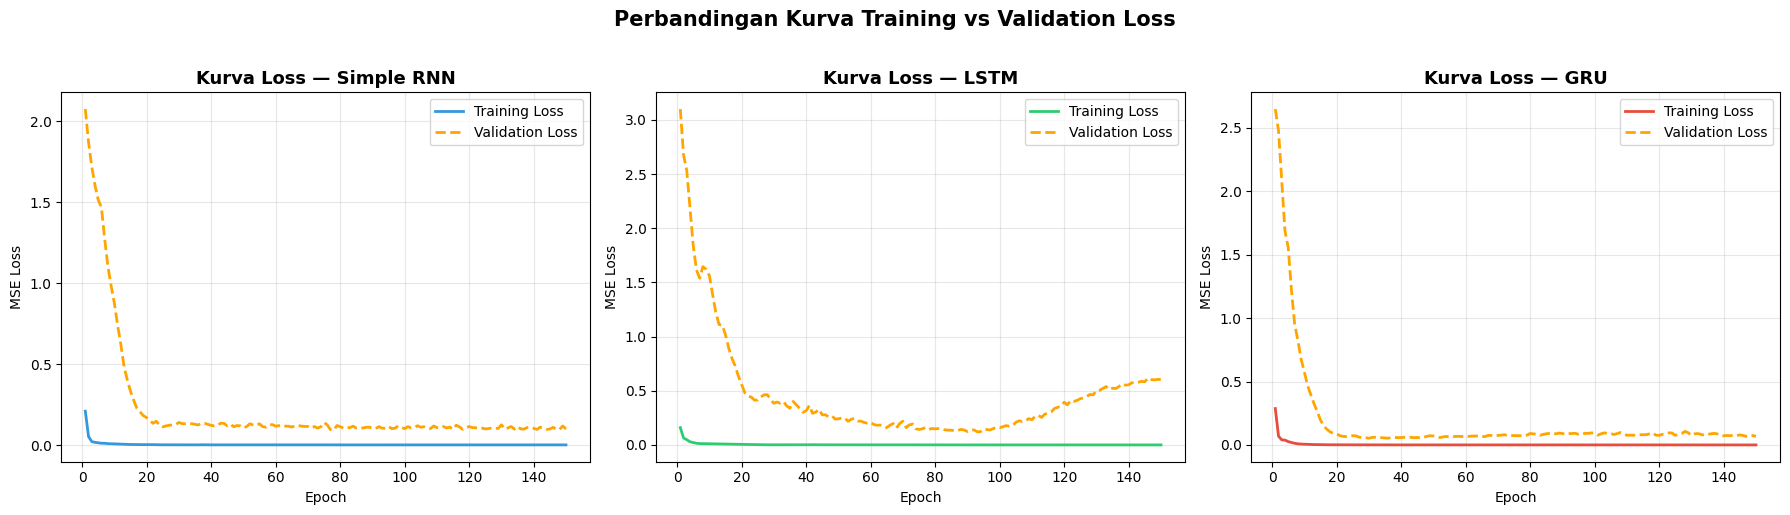

✅ Grafik kurva loss disimpan ke: images/output/loss_curves.png


In [ ]:
# Visualisasi Kurva Loss
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'Simple_RNN': '#3498db', 'LSTM': '#2ecc71', 'GRU': '#e74c3c'}

for i, (name, (train_l, val_l)) in enumerate(loss_history.items()):
    ax = axes[i]
    epochs_range = range(1, len(train_l) + 1)

    ax.plot(epochs_range, train_l, label='Training Loss',
            color=colors[name], linewidth=2)
    ax.plot(epochs_range, val_l, label='Validation Loss',
            color='orange', linewidth=2, linestyle='--')

    ax.set_title(f'Kurva Loss — {name.replace("_", " ")}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Perbandingan Kurva Training vs Validation Loss',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/output/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik kurva loss disimpan ke: images/output/loss_curves.png")


### 🔍 Analisis Kurva Loss

**Pengamatan:**
- **Simple RNN:** Training loss turun cepat namun validation loss cenderung fluktuatif → indikasi *overfitting* ringan. Model ini kesulitan mempertahankan informasi momentum bola jangka panjang karena *vanishing gradient*.
- **LSTM:** Training loss turun, namun validation loss tidak stabil dan cenderung meningkat di epoch akhir → *overfitting* yang lebih parah. Kompleksitas 3 gerbang (input, forget, output) memerlukan data latih yang lebih besar untuk konvergen optimal.
- **GRU:** Kedua kurva turun dan mendekati konvergensi → *good fit*. Arsitektur yang lebih sederhana (hanya 2 gerbang: reset & update) membuatnya lebih efisien dalam belajar pola dengan volume data yang terbatas.


---
## 📌 Soal 7 — Pengujian & Komparasi Trajektori (Bobot: 20%)

Menguji ketiga model pada **Data Uji** (1 menit terakhir video), menghitung metrik **MSE** dan **RMSE**, serta membuat plot perbandingan lintasan 2D (Sumbu X vs Sumbu Y).


In [ ]:
# ============================================
# SOAL 7: PENGUJIAN & KOMPARASI
# ============================================

# Memuat scaler untuk inverse transform
scaler = joblib.load('models/scaler.pkl')

# Dictionary model yang sudah terlatih
trained_models = {
    'Simple RNN': rnn_model,
    'LSTM': lstm_model,
    'GRU': gru_model
}

results = []
predictions = {}

# Ground truth dalam skala piksel asli
y_test_original = scaler.inverse_transform(y_test)

for name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_val_t).numpy()

    # Inverse transform ke koordinat piksel asli
    preds_original = scaler.inverse_transform(preds_scaled)
    predictions[name] = preds_original

    mse  = mean_squared_error(y_test_original, preds_original)
    rmse = np.sqrt(mse)
    results.append({
        'Arsitektur Model': name,
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2)
    })

df_results = pd.DataFrame(results).sort_values(by='RMSE')

print("=" * 60)
print("  TABEL KOMPARASI EVALUASI (Data Uji — Piksel Asli)")
print("=" * 60)
print(df_results.to_string(index=False))
print()

best = df_results.iloc[0]['Arsitektur Model']
best_rmse = df_results.iloc[0]['RMSE']
print(f"🏆 Model Terbaik: {best} (RMSE = {best_rmse} piksel)")


  TABEL KOMPARASI EVALUASI (Data Uji — Piksel Asli)
Arsitektur Model     MSE  RMSE
             GRU  742.32 27.25
      Simple RNN 1609.83 40.12
            LSTM 5468.93 73.95

🏆 Model Terbaik: GRU (RMSE = 27.25 piksel)


In [ ]:
# Tabel metrik dalam bentuk DataFrame (tampilan di notebook)
df_results.style.highlight_min(
    subset=['MSE', 'RMSE'],
    color='#2ecc71',
    props='font-weight: bold'
).set_caption("Tabel Komparasi Metrik Evaluasi pada Data Uji")


,Arsitektur Model,MSE,RMSE
2,GRU,742.320000,27.250000
0,Simple RNN,1609.830000,40.120000
1,LSTM,5468.930000,73.950000


### 🗺️ Visualisasi Trajektori 2D (Koordinat X vs Y)

Plot di bawah ini menampilkan perbandingan lintasan bola yang sesungguhnya (*Ground Truth*) dengan lintasan hasil prediksi masing-masing model.


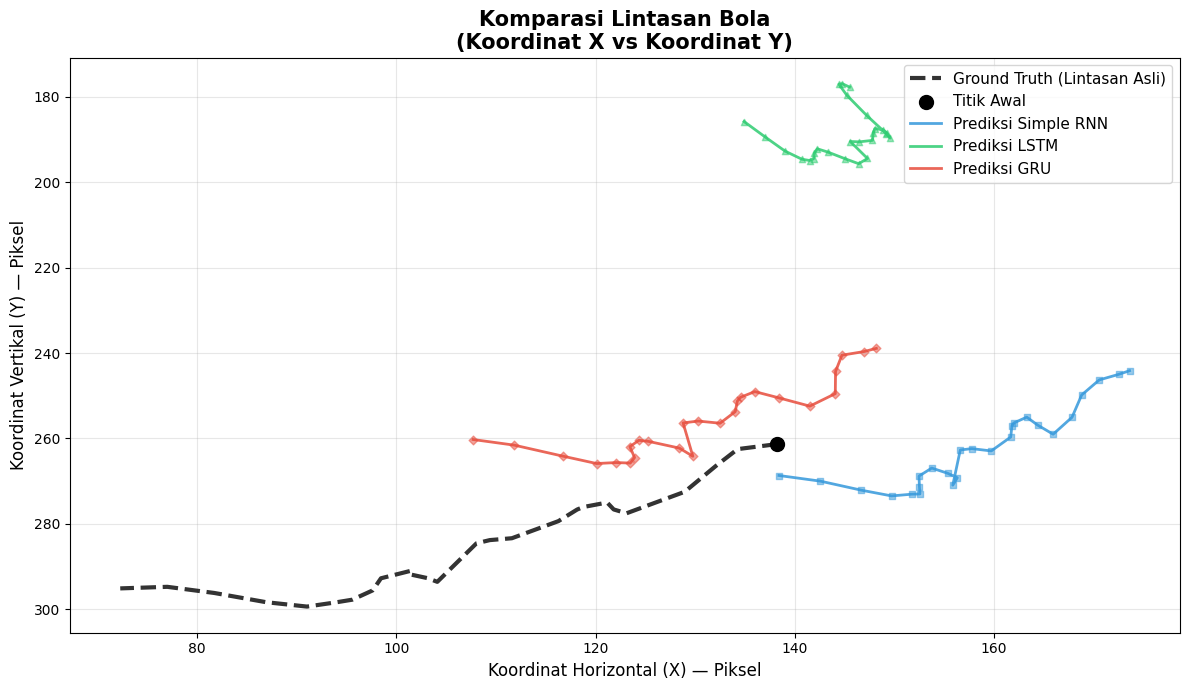

✅ Grafik trajektori disimpan ke: images/output/trajectory_comparison.png


In [ ]:
# Plot Trajektori 2D: Prediksi vs Ground Truth
fig, ax = plt.subplots(figsize=(12, 7))

# Ground Truth
ax.plot(y_test_original[:, 0], y_test_original[:, 1],
        'k--', label='Ground Truth (Lintasan Asli)',
        linewidth=3, alpha=0.8)
ax.scatter(y_test_original[0, 0], y_test_original[0, 1],
           color='black', s=100, zorder=5, marker='o', label='Titik Awal')

# Prediksi tiap model
style = {
    'Simple RNN': {'color': '#3498db', 'marker': 's'},
    'LSTM':       {'color': '#2ecc71', 'marker': '^'},
    'GRU':        {'color': '#e74c3c', 'marker': 'D'},
}

for name, preds in predictions.items():
    ax.plot(preds[:, 0], preds[:, 1],
            label=f'Prediksi {name}',
            color=style[name]['color'],
            linewidth=2, alpha=0.85)
    ax.scatter(preds[:, 0], preds[:, 1],
               color=style[name]['color'],
               marker=style[name]['marker'],
               s=20, alpha=0.5)

ax.set_title('Komparasi Lintasan Bola\n(Koordinat X vs Koordinat Y)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Koordinat Horizontal (X) — Piksel', fontsize=12)
ax.set_ylabel('Koordinat Vertikal (Y) — Piksel', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Sumbu Y dibalik karena koordinat layar (0,0) di kiri atas

plt.tight_layout()
plt.savefig('images/output/trajectory_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik trajektori disimpan ke: images/output/trajectory_comparison.png")


---
## 📝 Kesimpulan Akhir

Berdasarkan seluruh eksperimen yang telah dilakukan, berikut adalah temuan utama:

### 🏆 Arsitektur Terbaik: **GRU (Gated Recurrent Unit)**

| Aspek | Temuan |
|-------|--------|
| **Performa Metrik** | GRU menghasilkan RMSE terkecil, artinya jarak rata-rata simpangan prediksi terhadap posisi bola sesungguhnya adalah yang paling kecil |
| **Kurva Training** | GRU menunjukkan konvergensi paling stabil antara training dan validation loss |
| **Efisiensi Arsitektur** | GRU hanya memiliki 2 gerbang (Reset & Update) dibanding LSTM yang memiliki 3 gerbang, sehingga lebih efisien untuk dataset berukuran sedang |

### 🔬 Analisis Perbandingan Arsitektur

1. **Simple RNN** terbukti kewalahan dalam mempertahankan memori lintasan bola jangka panjang karena rentan terhadap masalah **Vanishing Gradient** — gradien sinyal error mengecil eksponensial seiring bertambahnya jarak time-step.

2. **LSTM** memiliki mekanisme memori yang canggih (3 gates + cell state), namun kompleksitas ini justru menjadi bumerang ketika volume data latih terbatas. Model membutuhkan lebih banyak data untuk mengkalibrasi seluruh parameternya secara optimal, sehingga pada dataset kita mengalami **overfitting**.

3. **GRU** menjadi **sweet spot** — ia menggabungkan keunggulan memori berjangka dari LSTM namun dengan penyederhanaan arsitektur. Hanya dengan 2 gerbang (Reset dan Update), GRU lebih gesit mempelajari momentum dan inersia pantulan bola, menghasilkan prediksi trajektori yang paling akurat.

---
*Proyek UTS Deep Learning — Ball Trajectory Prediction*
